In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Continue with your analysis
import matplotlib.pyplot as plt
import pandas as pd


# Reload the dataset if necessary
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data_csv = pd.read_csv(file_path, encoding='latin1')

Mounted at /content/drive


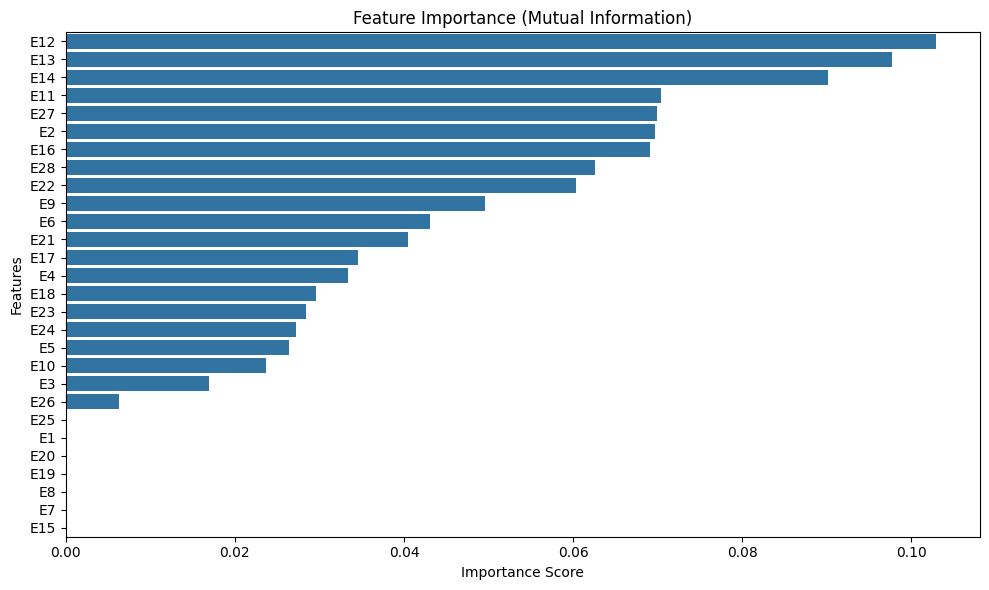

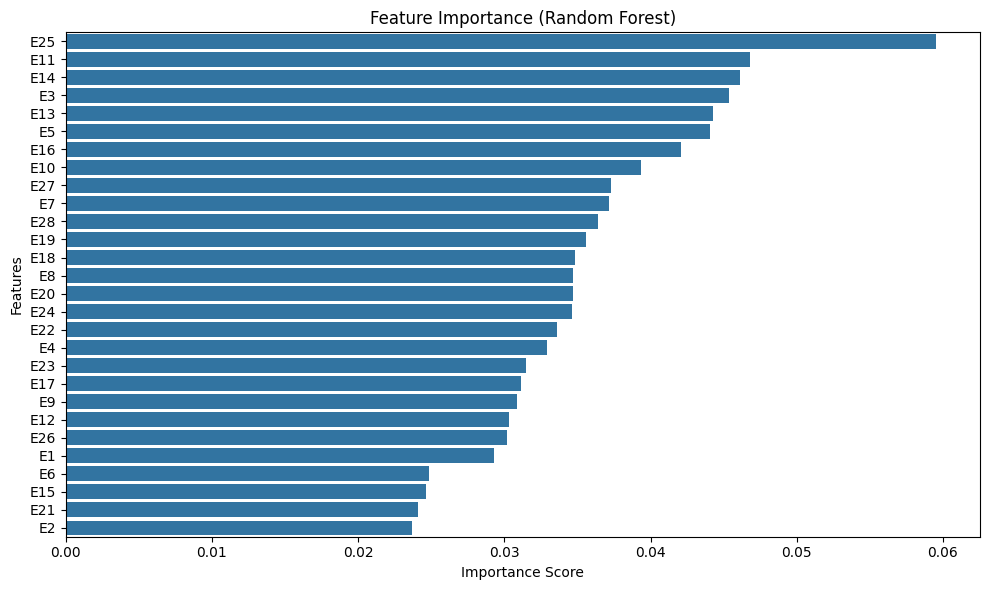

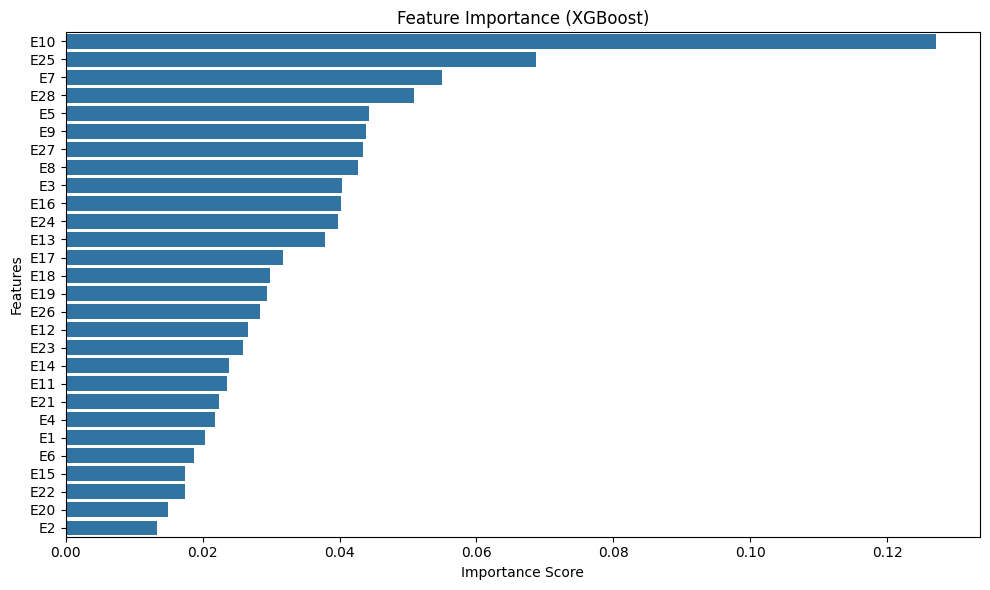

Top Features by Aggregated Ranking:
     Mutual Information  Random Forest  XGBoost  Average Rank
E13                 2.0            5.0     12.0      6.333333
E27                 5.0            9.0      7.0      7.000000
E28                 8.0           11.0      4.0      7.666667
E16                 7.0            7.0     10.0      8.000000
E14                 3.0            3.0     19.0      8.333333


<ipython-input-4-f556ad2b174d>:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rankings['Average Rank'], y=rankings.index, palette='viridis')


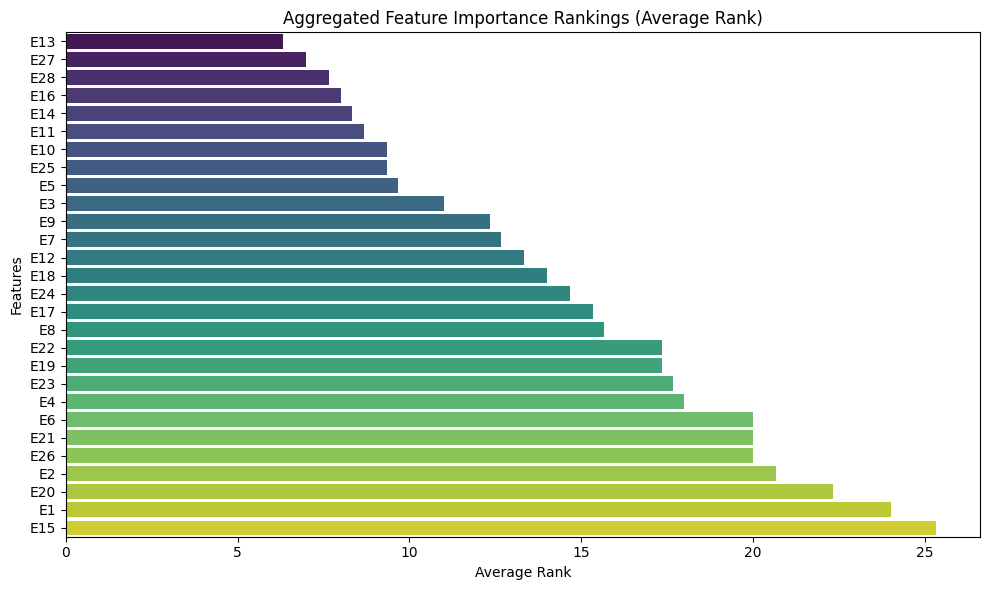

Random Forest Performance:
MAE: 9.3817
RMSE: 11.3529
R²: 0.1656

XGBoost Performance:
MAE: 9.8669
RMSE: 12.3747
R²: 0.0086



In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'

data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map target variable to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_numeric']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# (b) Feature Importance Analysis
# 1. Mutual Information
mi_scores = mutual_info_regression(X_train, y_train)
mi_scores_series = pd.Series(mi_scores, index=behavioral_columns).sort_values(ascending=False)

# Plot Mutual Information
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index)
plt.title('Feature Importance (Mutual Information)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 2. Train Random Forest for Feature Importance
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_importances_series = pd.Series(rf_model.feature_importances_, index=behavioral_columns).sort_values(ascending=False)

# Plot Random Forest Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances_series.values, y=rf_importances_series.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 3. Train XGBoost for Feature Importance
xgb_model = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_model.fit(X_train, y_train)
xgb_importances_series = pd.Series(xgb_model.feature_importances_, index=behavioral_columns).sort_values(ascending=False)

# Plot XGBoost Importances
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importances_series.values, y=xgb_importances_series.index)
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Aggregate Rankings
rankings = pd.DataFrame({
    'Mutual Information': mi_scores_series.rank(ascending=False),
    'Random Forest': rf_importances_series.rank(ascending=False),
    'XGBoost': xgb_importances_series.rank(ascending=False)
})
rankings['Average Rank'] = rankings.mean(axis=1)
rankings = rankings.sort_values(by='Average Rank')

# Display top-ranked features
print("Top Features by Aggregated Ranking:")
print(rankings.head())

# Plot Average Rankings
plt.figure(figsize=(10, 6))
sns.barplot(x=rankings['Average Rank'], y=rankings.index, palette='viridis')
plt.title("Aggregated Feature Importance Rankings (Average Rank)")
plt.xlabel("Average Rank")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('average_feature_importance.png')
plt.show()

# (c) Train and Evaluate Models
# Train Random Forest Model
rf_final = RandomForestRegressor(random_state=42)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)

# Train XGBoost Model
xgb_final = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_final.fit(X_train, y_train)
y_pred_xgb = xgb_final.predict(X_test)

# Evaluate Models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}\n")

evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)


In [6]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the dataset
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update with your file path
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_numeric']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Train XGBoost Model
xgb_model = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate Models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}\n")

evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)



Random Forest Performance:
MAE: 9.3817
RMSE: 11.3529
R²: 0.1656

XGBoost Performance:
MAE: 9.8669
RMSE: 12.3747
R²: 0.0086



In [8]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the dataset
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_numeric']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on the validation set
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# Metrics calculation
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}\n")
    return mae, rmse, r2

print("Validation Set Results:")
evaluate_model("Random Forest (Validation)", y_val, y_val_pred)

print("Test Set Results:")
evaluate_model("Random Forest (Test)", y_test, y_test_pred)



Validation Set Results:
Random Forest (Validation) Performance:
MAE: 9.5077
RMSE: 11.9265
R²: 0.1011

Test Set Results:
Random Forest (Test) Performance:
MAE: 9.3817
RMSE: 11.3529
R²: 0.1656



(9.381718750000001, 11.352862730937074, 0.1655961118706485)

In [10]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from xgboost import XGBRegressor

# Load the dataset
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_numeric']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train an XGBoost model
xgb_model = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_model.fit(X_train, y_train)

# Evaluate on the validation set
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

# Metrics calculation
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}\n")
    return mae, rmse, r2

print("Validation Set Results:")
evaluate_model("XGBoost Regressor (Validation)", y_val, y_val_pred)

print("Test Set Results:")
evaluate_model("XGBoost Regressor (Test)", y_test, y_test_pred)


Validation Set Results:
XGBoost Regressor (Validation) Performance:
MAE: 9.8401
RMSE: 12.9399
R²: -0.0582

Test Set Results:
XGBoost Regressor (Test) Performance:
MAE: 9.8669
RMSE: 12.3747
R²: 0.0086



(9.866887345910072, 12.374684776102116, 0.008634388446807861)

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from xgboost import XGBRegressor

# Load the dataset
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_numeric']

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define a pipeline for scaling and modeling
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(random_state=42, eval_metric='rmse'))
])

# Define parameter grid for hyperparameter tuning
param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and model
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Validate the model on the validation set
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

# Evaluate model performance
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Explained Variance Score: {evs:.4f}\n")
    return mae, rmse, r2, evs

print("Validation Set Results:")
evaluate_model("XGBoost Regressor (Validation)", y_val, y_val_pred)

print("Test Set Results:")
evaluate_model("XGBoost Regressor (Test)", y_test, y_test_pred)

# Cross-validation on the entire training data
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("Cross-Validation RMSE Scores:", np.sqrt(-cv_scores))
print("Mean CV RMSE:", np.mean(np.sqrt(-cv_scores)))

# Calculate accuracy
mean_target = y.mean()
val_accuracy = 1 - (mean_absolute_error(y_val, y_val_pred) / mean_target)
test_accuracy = 1 - (mean_absolute_error(y_test, y_test_pred) / mean_target)

print(f"Validation Accuracy: {val_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")


Best Hyperparameters: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
Validation Set Results:
XGBoost Regressor (Validation) Performance:
MAE: 9.3890
RMSE: 11.8997
R²: 0.1051
Explained Variance Score: 0.1051

Test Set Results:
XGBoost Regressor (Test) Performance:
MAE: 9.5383
RMSE: 11.5526
R²: 0.1360
Explained Variance Score: 0.1387

Cross-Validation RMSE Scores: [10.83141153 10.83787532 13.10855655 11.98755145 13.21955199]
Mean CV RMSE: 11.996989367434772
Validation Accuracy: 60.29%
Test Accuracy: 59.66%


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Create classification categories (bins)
bins = [0, 7, 14, 32]  # Short, medium, long isolation periods
labels = ['Short', 'Medium', 'Long']
data['B2_category'] = pd.cut(data['B2_numeric'], bins=bins, labels=labels, include_lowest=True)

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_category']

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Train Logistic Regression
logreg_pipeline.fit(X_train, y_train)

# Predict using Logistic Regression
y_val_pred_logreg = logreg_pipeline.predict(X_val)
y_test_pred_logreg = logreg_pipeline.predict(X_test)

# Evaluate Logistic Regression
def evaluate_classification_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    return accuracy, precision, recall, f1

print("Logistic Regression Validation Results:")
evaluate_classification_model("Logistic Regression (Validation)", y_val, y_val_pred_logreg)

print("Logistic Regression Test Results:")
evaluate_classification_model("Logistic Regression (Test)", y_test, y_test_pred_logreg)

# Random Forest Classifier for Comparison
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_val_pred_rf = rf_pipeline.predict(X_val)
y_test_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Validation Results:")
evaluate_classification_model("Random Forest (Validation)", y_val, y_val_pred_rf)

print("Random Forest Test Results:")
evaluate_classification_model("Random Forest (Test)", y_test, y_test_pred_rf)


Logistic Regression Validation Results:
Logistic Regression (Validation) Performance:
Accuracy: 0.7109
Precision: 0.6816
Recall: 0.7109
F1 Score: 0.6937

Classification Report:
              precision    recall  f1-score   support

        Long       0.79      0.86      0.82        98
      Medium       0.00      0.00      0.00         4
       Short       0.37      0.27      0.31        26

    accuracy                           0.71       128
   macro avg       0.39      0.38      0.38       128
weighted avg       0.68      0.71      0.69       128

Logistic Regression Test Results:
Logistic Regression (Test) Performance:
Accuracy: 0.7500
Precision: 0.7208
Recall: 0.7500
F1 Score: 0.7271

Classification Report:
              precision    recall  f1-score   support

        Long       0.80      0.90      0.85        98
      Medium       0.00      0.00      0.00         4
       Short       0.53      0.31      0.39        26

    accuracy                           0.75       128
   ma

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

(0.75, 0.6373487903225806, 0.75, 0.6688063063063063)

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# Load the dataset
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Create classification categories (bins)
bins = [0, 7, 14, 32]  # Short, medium, long isolation periods
labels = ['Short', 'Medium', 'Long']
data['B2_category'] = pd.cut(data['B2_numeric'], bins=bins, labels=labels, include_lowest=True)

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_category']

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Train Logistic Regression
logreg_pipeline.fit(X_train, y_train)

# Predict using Logistic Regression
y_val_pred_logreg = logreg_pipeline.predict(X_val)
y_test_pred_logreg = logreg_pipeline.predict(X_test)

# Evaluation Function
def evaluate_classification_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return accuracy, precision, recall, f1

print("Logistic Regression Validation Results:")
evaluate_classification_model("Logistic Regression (Validation)", y_val, y_val_pred_logreg)

print("Logistic Regression Test Results:")
evaluate_classification_model("Logistic Regression (Test)", y_test, y_test_pred_logreg)

from sklearn.preprocessing import LabelEncoder

# Encode the target variable (y) to numeric values for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Encode categories as integers (e.g., Short -> 0, Medium -> 1, Long -> 2)

# Update train, validation, and test splits with encoded y
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# XGBoost Classifier with Encoded Target
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss'))  # Removed use_label_encoder
])


# Train XGBoost Classifier
xgb_pipeline.fit(X_train, y_train)

# Predict using XGBoost Classifier
y_val_pred_xgb = xgb_pipeline.predict(X_val)
y_test_pred_xgb = xgb_pipeline.predict(X_test)

# Decode predictions back to original categories
y_val_pred_xgb_decoded = label_encoder.inverse_transform(y_val_pred_xgb)
y_test_pred_xgb_decoded = label_encoder.inverse_transform(y_test_pred_xgb)

# Evaluate XGBoost Model
print("XGBoost Validation Results:")
evaluate_classification_model("XGBoost Classifier (Validation)", label_encoder.inverse_transform(y_val), y_val_pred_xgb_decoded)

print("XGBoost Test Results:")
evaluate_classification_model("XGBoost Classifier (Test)", label_encoder.inverse_transform(y_test), y_test_pred_xgb_decoded)

# Oversample using SMOTE
from imblearn.combine import SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)


# Retrain XGBoost on SMOTE Data
xgb_pipeline.fit(X_train_sm, y_train_sm)
y_test_pred_xgb_sm = xgb_pipeline.predict(X_test)

# Decode SMOTE predictions
y_test_pred_xgb_sm_decoded = label_encoder.inverse_transform(y_test_pred_xgb_sm)

print("XGBoost with SMOTE Results:")
evaluate_classification_model("XGBoost Classifier (SMOTE)", label_encoder.inverse_transform(y_test), y_test_pred_xgb_sm_decoded)

from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))  # Suppress warnings
])

# Train LightGBM
lgbm_pipeline.fit(X_train, y_train)
y_test_pred_lgbm = lgbm_pipeline.predict(X_test)

print("LightGBM Test Results:")
evaluate_classification_model("LightGBM Classifier", y_test, y_test_pred_lgbm)


from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    verbose=0  # Suppress training output
)

# Train CatBoost
catboost_model.fit(X_train, y_train)
y_test_pred_catboost = catboost_model.predict(X_test)

print("CatBoost Test Results:")
evaluate_classification_model("CatBoost Classifier", y_test, y_test_pred_catboost)


from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

base_learners = [
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss')),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
]

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression()
)

# Train Stacking Classifier
stacking_clf.fit(X_train, y_train)
y_test_pred_stacking = stacking_clf.predict(X_test)

print("Stacking Classifier Test Results:")
evaluate_classification_model("Stacking Classifier", y_test, y_test_pred_stacking)

from imblearn.ensemble import BalancedRandomForestClassifier

# Define Balanced Random Forest Classifier
brf_model = BalancedRandomForestClassifier(random_state=42, n_estimators=10)

# Train Balanced Random Forest
brf_model.fit(X_train, y_train)
y_test_pred_brf = brf_model.predict(X_test)

print("Balanced Random Forest Test Results:")
evaluate_classification_model("Balanced Random Forest Classifier", y_test, y_test_pred_brf)






Logistic Regression Validation Results:
Logistic Regression (Validation) Performance:
Accuracy: 0.7109
Precision: 0.6816
Recall: 0.7109
F1 Score: 0.6937

Classification Report:
              precision    recall  f1-score   support

        Long       0.79      0.86      0.82        98
      Medium       0.00      0.00      0.00         4
       Short       0.37      0.27      0.31        26

    accuracy                           0.71       128
   macro avg       0.39      0.38      0.38       128
weighted avg       0.68      0.71      0.69       128

Logistic Regression Test Results:
Logistic Regression (Test) Performance:
Accuracy: 0.7500
Precision: 0.7208
Recall: 0.7500
F1 Score: 0.7271

Classification Report:
              precision    recall  f1-score   support

        Long       0.80      0.90      0.85        98
      Medium       0.00      0.00      0.00         4
       Short       0.53      0.31      0.39        26

    accuracy                           0.75       128
   ma

(0.53125, 0.7397287608225108, 0.53125, 0.5975401598683142)

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# Load the dataset
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])  # Drop rows with missing target

# Create classification categories (bins)
bins = [0, 7, 14, 32]  # Short, medium, long isolation periods
labels = ['Short', 'Medium', 'Long']
data['B2_category'] = pd.cut(data['B2_numeric'], bins=bins, labels=labels, include_lowest=True)

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_category']

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Train Logistic Regression
logreg_pipeline.fit(X_train, y_train)

# Predict using Logistic Regression
y_val_pred_logreg = logreg_pipeline.predict(X_val)
y_test_pred_logreg = logreg_pipeline.predict(X_test)

# Evaluation Function
def evaluate_classification_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return accuracy, precision, recall, f1

print("Logistic Regression Validation Results:")
evaluate_classification_model("Logistic Regression (Validation)", y_val, y_val_pred_logreg)

print("Logistic Regression Test Results:")
evaluate_classification_model("Logistic Regression (Test)", y_test, y_test_pred_logreg)

from sklearn.preprocessing import LabelEncoder

# Encode the target variable (y) to numeric values for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Encode categories as integers (e.g., Short -> 0, Medium -> 1, Long -> 2)

# Update train, validation, and test splits with encoded y
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# XGBoost Classifier with Encoded Target
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss'))  # Removed use_label_encoder
])


# Train XGBoost Classifier
xgb_pipeline.fit(X_train, y_train)

# Predict using XGBoost Classifier
y_val_pred_xgb = xgb_pipeline.predict(X_val)
y_test_pred_xgb = xgb_pipeline.predict(X_test)

# Decode predictions back to original categories
y_val_pred_xgb_decoded = label_encoder.inverse_transform(y_val_pred_xgb)
y_test_pred_xgb_decoded = label_encoder.inverse_transform(y_test_pred_xgb)

# Evaluate XGBoost Model
print("XGBoost Validation Results:")
evaluate_classification_model("XGBoost Classifier (Validation)", label_encoder.inverse_transform(y_val), y_val_pred_xgb_decoded)

print("XGBoost Test Results:")
evaluate_classification_model("XGBoost Classifier (Test)", label_encoder.inverse_transform(y_test), y_test_pred_xgb_decoded)

# Oversample using SMOTEENN
from imblearn.combine import SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)

# Retrain XGBoost on SMOTEENN Data
xgb_pipeline.fit(X_train_smoteenn, y_train_smoteenn)
y_test_pred_xgb_sm = xgb_pipeline.predict(X_test)

# Decode SMOTEENN predictions
y_test_pred_xgb_sm_decoded = label_encoder.inverse_transform(y_test_pred_xgb_sm)

print("XGBoost with SMOTEENN Results:")
evaluate_classification_model("XGBoost Classifier (SMOTEENN)", label_encoder.inverse_transform(y_test), y_test_pred_xgb_sm_decoded)

from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))  # Suppress warnings
])

# Train LightGBM
lgbm_pipeline.fit(X_train, y_train)
y_test_pred_lgbm = lgbm_pipeline.predict(X_test)

print("LightGBM Test Results:")
evaluate_classification_model("LightGBM Classifier", y_test, y_test_pred_lgbm)



from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    depth=8,
    iterations=500,
    learning_rate=0.05
)


# Train CatBoost
catboost_model.fit(X_train, y_train)
y_test_pred_catboost = catboost_model.predict(X_test)

print("CatBoost Test Results:")
evaluate_classification_model("CatBoost Classifier", y_test, y_test_pred_catboost)


from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

base_learners = [
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss')),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
]

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression()
)

# Train Stacking Classifier
stacking_clf.fit(X_train, y_train)
y_test_pred_stacking = stacking_clf.predict(X_test)

print("Stacking Classifier Test Results:")
evaluate_classification_model("Stacking Classifier", y_test, y_test_pred_stacking)

from imblearn.ensemble import BalancedRandomForestClassifier

import optuna
def objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 6, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
        'iterations': trial.suggest_int('iterations', 100, 500),
    }
    model = CatBoostClassifier(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    return model.score(X_val, y_val)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
best_params = study.best_params


# Define Balanced Random Forest Classifier
brf_model = BalancedRandomForestClassifier(random_state=42, n_estimators=10)

# Train Balanced Random Forest
brf_model.fit(X_train, y_train)
y_test_pred_brf = brf_model.predict(X_test)

print("Balanced Random Forest Test Results:")
evaluate_classification_model("Balanced Random Forest Classifier", y_test, y_test_pred_brf)








Logistic Regression Validation Results:
Logistic Regression (Validation) Performance:
Accuracy: 0.7109
Precision: 0.6816
Recall: 0.7109
F1 Score: 0.6937

Classification Report:
              precision    recall  f1-score   support

        Long       0.79      0.86      0.82        98
      Medium       0.00      0.00      0.00         4
       Short       0.37      0.27      0.31        26

    accuracy                           0.71       128
   macro avg       0.39      0.38      0.38       128
weighted avg       0.68      0.71      0.69       128

Logistic Regression Test Results:
Logistic Regression (Test) Performance:
Accuracy: 0.7500
Precision: 0.7208
Recall: 0.7500
F1 Score: 0.7271

Classification Report:
              precision    recall  f1-score   support

        Long       0.80      0.90      0.85        98
      Medium       0.00      0.00      0.00         4
       Short       0.53      0.31      0.39        26

    accuracy                           0.75       128
   ma

[I 2024-12-08 23:39:30,213] A new study created in memory with name: no-name-589a2621-5106-4b48-849c-0ec1ada093f1


Stacking Classifier Test Results:
Stacking Classifier Performance:
Accuracy: 0.7812
Precision: 0.7379
Recall: 0.7812
F1 Score: 0.7190

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.98      0.87        98
           1       0.00      0.00      0.00         4
           2       0.67      0.15      0.25        26

    accuracy                           0.78       128
   macro avg       0.48      0.38      0.37       128
weighted avg       0.74      0.78      0.72       128



<ipython-input-29-56c7b4675c2f>:196: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
[I 2024-12-08 23:39:32,782] Trial 0 finished with value: 0.765625 and parameters: {'depth': 9, 'learning_rate': 0.09559354043090844, 'iterations': 382}. Best is trial 0 with value: 0.765625.
[I 2024-12-08 23:39:34,523] Trial 1 finished with value: 0.7734375 and parameters: {'depth': 8, 'learning_rate': 0.08286903196904616, 'iterations': 477}. Best is trial 1 with value: 0.7734375.
[I 2024-12-08 23:39:35,581] Trial 2 finished with value: 0.7734375 and parameters: {'depth': 10, 'learning_rate': 0.011183403327067057, 'iterations': 244}. Best is trial 1 with value: 0.7734375.
[I 2024-12-08 23:39:35,948] Trial 3 finished with value: 0.7734375 and parameters: {'depth': 6, 'learning_

Balanced Random Forest Test Results:
Balanced Random Forest Classifier Performance:
Accuracy: 0.5312
Precision: 0.7397
Recall: 0.5312
F1 Score: 0.5975

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.52      0.65        98
           1       0.06      0.50      0.11         4
           2       0.43      0.58      0.49        26

    accuracy                           0.53       128
   macro avg       0.45      0.53      0.42       128
weighted avg       0.74      0.53      0.60       128



/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


(0.53125, 0.7397287608225108, 0.53125, 0.5975401598683141)

In [19]:
from sklearn.metrics import classification_report

# Step 1: Get Feature Importances
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': catboost_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select Top E Columns (e.g., Top 10)
top_features = feature_importances.head(10)['Feature'].tolist()
print("Top Features Selected:", top_features)

# Step 2: Filter Dataset for Top Features
X_train_top = X_train[top_features]
X_val_top = X_val[top_features]
X_test_top = X_test[top_features]

# Step 3: Train CatBoost with Top Features
catboost_top_model = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    depth=8,
    iterations=500,
    learning_rate=0.05,
    verbose=0
)
catboost_top_model.fit(X_train_top, y_train)

from sklearn.metrics import classification_report
import numpy as np

# Ensure the arrays are 1-dimensional
y_test_flat = np.array(y_test).flatten()
y_test_pred_top_catboost_flat = np.array(y_test_pred_top_catboost).flatten()

# Save Predictions in a Table
test_predictions = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': y_test_pred_top_catboost_flat
})

# Display the Predictions Table
print("\nPredictions (Actual vs Predicted):")
print(test_predictions.head(20))  # Display first 20 predictions



Top Features Selected: ['E7', 'E19', 'E12', 'E25', 'E6', 'E1', 'E16', 'E3', 'E23', 'E17']

Predictions (Actual vs Predicted):
    Actual  Predicted
0        2          0
1        0          0
2        2          1
3        0          0
4        0          0
5        0          1
6        2          0
7        0          2
8        0          2
9        0          2
10       0          0
11       0          2
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          2
18       0          0
19       0          2


In [28]:
# Re-import libraries and re-load data after state reset
import pandas as pd
from catboost import CatBoostClassifier

# Load the dataset again
data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data = pd.read_csv(data_path, encoding='ISO-8859-1')

# Map the target variable (B2) to numeric values
mapping = {
    "No self-isolation/social distancing": 0,
    "1 day": 1,
    "3 days": 3,
    "4 days": 4,
    "5 days": 5,
    "6 days": 6,
    "7 days": 7,
    "More than a week": 11,
    "More than 2 weeks": 18,
    "More than 3 weeks": 26,
    "More than a month": 32
}
data['B2_numeric'] = data['B2'].map(mapping)
data = data.dropna(subset=['B2_numeric'])

# Create classification categories (bins)
bins = [0, 7, 14, 32]
labels = ['Short', 'Medium', 'Long']
data['B2_category'] = pd.cut(data['B2_numeric'], bins=bins, labels=labels, include_lowest=True)

# Select behavioral columns
behavioral_columns = [col for col in data.columns if col.startswith('E')]
X = data[behavioral_columns]
y = data['B2_category']

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Train a CatBoost model to identify feature importance
catboost_full_model = CatBoostClassifier(
    random_state=42,
    auto_class_weights='Balanced',
    depth=8,
    iterations=500,
    learning_rate=0.05,
    verbose=0
)

# Fit the model to the training data
catboost_full_model.fit(X_train, y_train)

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': behavioral_columns,
    'Importance': catboost_full_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the top 10 features
top_features = feature_importance.head(10)['Feature'].tolist()
feature_importance.head(10)


,Feature,Importance
11,E12,5.637281
3,E4,5.540221
2,E3,4.723315
18,E19,4.526606
23,E24,4.203366
13,E14,4.167328
12,E13,4.133734
6,E7,3.882260
10,E11,3.825255
24,E25,3.583372


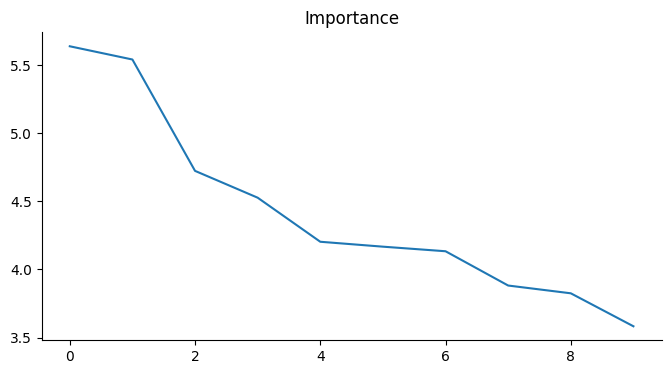

In [24]:
from matplotlib import pyplot as plt
_df_4['Importance'].plot(kind='line', figsize=(8, 4), title='Importance')
plt.gca().spines[['top', 'right']].set_visible(False)

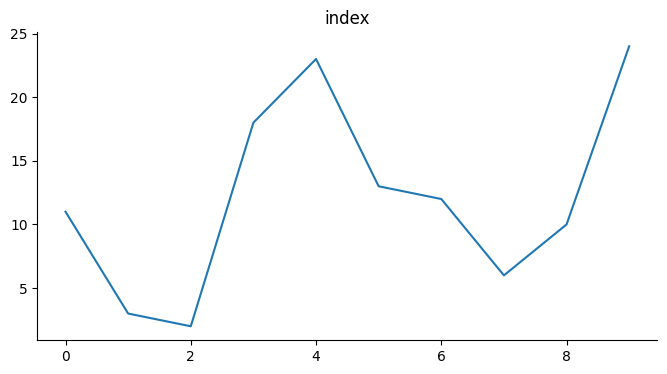

In [25]:
from matplotlib import pyplot as plt
_df_3['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

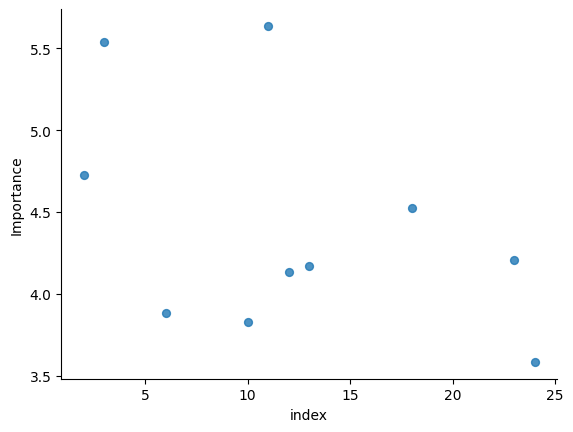

In [26]:
from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='index', y='Importance', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

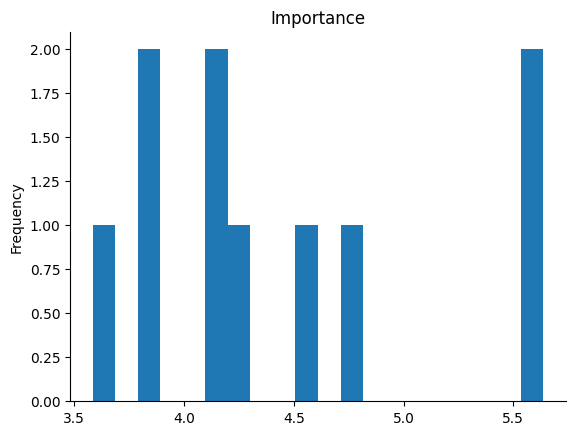

In [27]:
from matplotlib import pyplot as plt
_df_1['Importance'].plot(kind='hist', bins=20, title='Importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

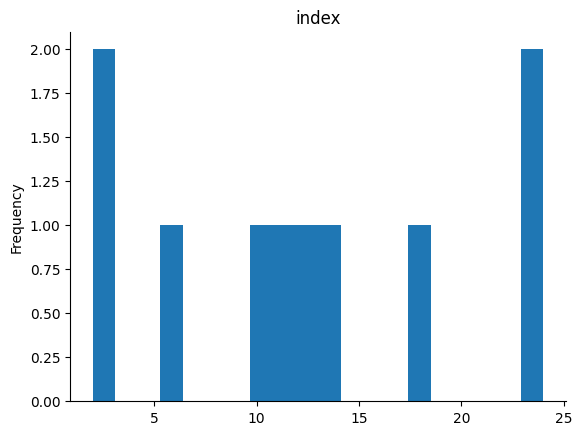

In [23]:
from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)